<a href="https://colab.research.google.com/github/OutisAyo/council-classifier-/blob/main/notebooks/04_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Automated Classification and Prioritisation of Local Council Service Requests in the UK
## Notebook 04 — Logistic Regression Classifier (Department Prediction)

**Author:** Fashina Fuad Ayomide  
**MSc Data Science, University of South Wales**

This notebook builds a Logistic Regression classifier to predict the assigned department from the request text, and compares it against the Naive Bayes baseline.

## Mounting Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing the libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the processed data

In [4]:
processed_dir = '/content/drive/MyDrive/council-classifier/processed'

X_train = np.load(f'{processed_dir}/X_train.npy', allow_pickle=True)
X_test = np.load(f'{processed_dir}/X_test.npy', allow_pickle=True)
y_dept_train = np.load(f'{processed_dir}/y_dept_train.npy', allow_pickle=True)
y_dept_test = np.load(f'{processed_dir}/y_dept_test.npy', allow_pickle=True)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 203501
Test set size: 50876


## Converting text to numerical features using Bag of Words

Same vectorisation approach as Notebook 03, so the two models are compared on identical input features.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=1500)
X_train_vec = cv.fit_transform(X_train).toarray()
X_test_vec = cv.transform(X_test).toarray()

print("Training matrix shape:", X_train_vec.shape)
print("Test matrix shape:", X_test_vec.shape)

Training matrix shape: (203501, 579)
Test matrix shape: (50876, 579)


## Training the Logistic Regression model on the Training set

In [6]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(random_state=0, max_iter=1000)
classifier.fit(X_train_vec, y_dept_train)

LogisticRegression(max_iter=1000, random_state=0)

## Predicting the Test set results

In [7]:
y_pred = classifier.predict(X_test_vec)

print("Sample predictions vs actual:")
comparison = pd.DataFrame({'Predicted': y_pred[:15], 'Actual': y_dept_test[:15]})
print(comparison)

Sample predictions vs actual:
                   Predicted                    Actual
0           Waste Management          Waste Management
1         Pollution Division        Pollution Division
2           Waste Management          Waste Management
3         Pollution Division        Pollution Division
4           Waste Management          Waste Management
5   Food and Safety Division  Food and Safety Division
6           Waste Management          Waste Management
7           Waste Management          Waste Management
8         Licensing Division        Licensing Division
9           Waste Management          Waste Management
10          Waste Management          Waste Management
11          Waste Management          Waste Management
12        Pollution Division        Pollution Division
13          Waste Management          Waste Management
14          Waste Management          Waste Management


## Making the Confusion Matrix

In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cm = confusion_matrix(y_dept_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy_score(y_dept_test, y_pred))

Confusion Matrix:
[[ 1180     1     2     0     0     0]
 [    1  2095     0     2     0     5]
 [    0     1  1598     2     4     0]
 [    1     6     0  6391     0     6]
 [    2     1     2     3   175     1]
 [    0     1     0    31     0 39365]]

Accuracy: 0.9985847944020756


## Classification Report

In [19]:
print(classification_report(y_dept_test, y_pred))

                            precision    recall  f1-score   support

  Food and Safety Division       1.00      1.00      1.00      1183
          Housing Division       1.00      1.00      1.00      2103
        Licensing Division       1.00      1.00      1.00      1605
        Pollution Division       0.99      1.00      1.00      6404
Trading Standards Division       0.98      0.95      0.96       184
          Waste Management       1.00      1.00      1.00     39397

                  accuracy                           1.00     50876
                 macro avg       0.99      0.99      0.99     50876
              weighted avg       1.00      1.00      1.00     50876



## Visualising the Confusion Matrix

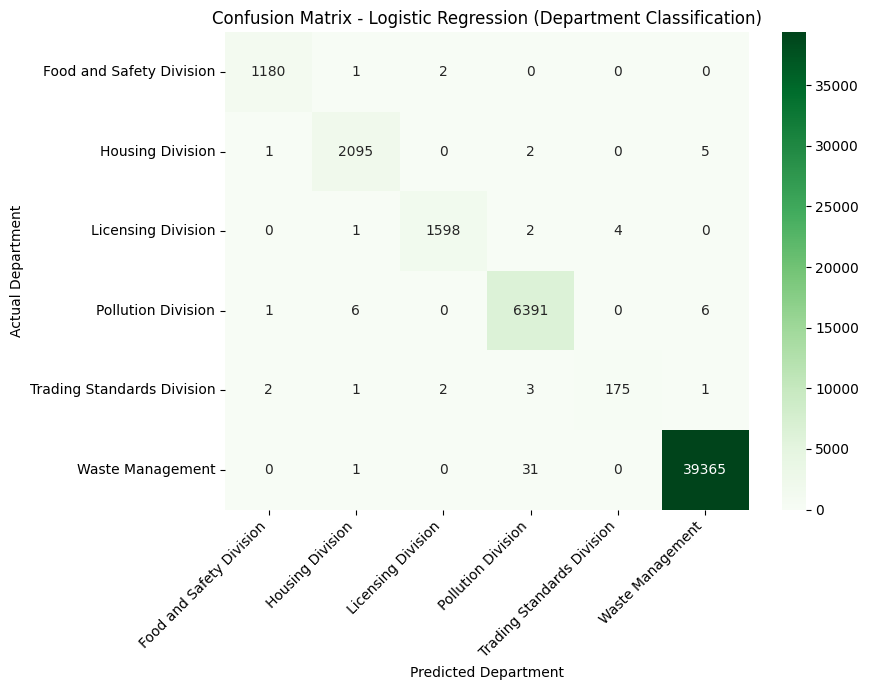

In [20]:
plt.figure(figsize=(9, 7))
unique_labels = sorted(set(y_dept_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Confusion Matrix - Logistic Regression (Department Classification)')
plt.xlabel('Predicted Department')
plt.ylabel('Actual Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Appending results to the comparison file

In [22]:
from sklearn.metrics import f1_score

results_path = '/content/drive/MyDrive/council-classifier/processed/model_results.csv'
results_df = pd.read_csv(results_path)

new_result = {
    'model': 'Logistic Regression',
    'accuracy': accuracy_score(y_dept_test, y_pred),
    'f1_macro': f1_score(y_dept_test, y_pred, average='macro'),
    'f1_weighted': f1_score(y_dept_test, y_pred, average='weighted')
}

results_df = pd.concat([results_df, pd.DataFrame([new_result])], ignore_index=True)
results_df.to_csv(results_path, index=False)

print(results_df)

                 model  accuracy  f1_macro  f1_weighted
0          Naive Bayes  0.997956  0.979528     0.997955
1  Logistic Regression  0.998585  0.991498     0.998584
